### Step 1: Install Dependencies

In [ ]:
! pip install torch transformers datasets accelerate seqeval

> You **MUST** work with GPU, so check first: 

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
else:
    print("Please switch to a GPU-enabled environment.")

GPU is available!


### Step 2: Import Libraries

In [ ]:
from collections import Counter

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from seqeval.metrics import precision_score, recall_score, f1_score
from torch.quantization import quantize_dynamic

### Step 3: Dataset Preparation

#### 3.1: Load Data

In [9]:
# Load "lhoestq/conll2003" dataset using HuggingFace datasets library
import pandas as pd
dataset = load_dataset("lhoestq/conll2003")
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

#### 3.2: Show Data

In [10]:
# Show samples of data before start working
data_train = dataset["train"].to_pandas()
data_train.head()

,id,tokens,pos_tags,chunk_tags,ner_tags
0,0,"[EU, rejects, German, call, to, boycott, Briti...","[22, 42, 16, 21, 35, 37, 16, 21, 7]","[11, 21, 11, 12, 21, 22, 11, 12, 0]","[3, 0, 7, 0, 0, 0, 7, 0, 0]"
1,1,"[Peter, Blackburn]","[22, 22]","[11, 12]","[1, 2]"
2,2,"[BRUSSELS, 1996-08-22]","[22, 11]","[11, 12]","[5, 0]"
3,3,"[The, European, Commission, said, on, Thursday...","[12, 22, 22, 38, 15, 22, 28, 38, 15, 16, 21, 3...","[11, 12, 12, 21, 13, 11, 11, 21, 13, 11, 12, 1...","[0, 3, 4, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, ..."
4,4,"[Germany, 's, representative, to, the, Europea...","[22, 27, 21, 35, 12, 22, 22, 27, 16, 21, 22, 2...","[11, 11, 12, 13, 11, 12, 12, 11, 12, 12, 12, 1...","[5, 0, 0, 0, 0, 3, 4, 0, 0, 0, 1, 2, 0, 0, 0, ..."


In [12]:
# Check Data Balancing
all_tags = data_train["ner_tags"].explode()
all_tags.value_counts().sort_index()

ner_tags
0    169578
1      6600
2      4528
3      6321
4      3704
5      7140
6      1157
7      3438
8      1155
Name: count, dtype: int64

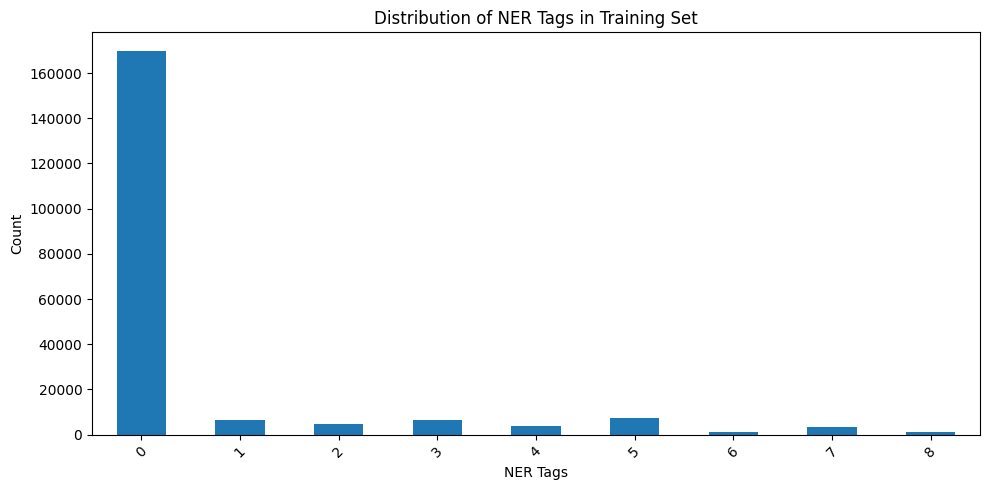

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
all_tags.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of NER Tags in Training Set")
plt.xlabel("NER Tags")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.3: Data Formatting
> Convert dataset into BERT-compatible format
<br>FROM:<br>
{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}
 <br><br>
 TO:<br>
 {'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0],
 'input_ids': [101,
  7270,
  22961,
  1528,
  1840,
  1106,
  21423,
  1418,
  2495,
  12913,
  119,
  102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [-100, 3, 0, 7, 0, 0, 0, 7, 0, 0, 0, -100]}

Where:
- input_ids will be the X and labels will be the Y
- 101 token id is the <sos> token
- 102 token id is the <eos> token
- -100 is the label for <sos> and <eos>

In [18]:
# use the following tokenizer "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
model = AutoModelForTokenClassification.from_pretrained("bert-base-cased", num_labels=9)

d:\anaconda\envs\iti-nlp\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\basil\.cache\huggingface\hub\models--bert-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5628.29it/s]
[transformers] BertForTokenClassification LOAD REPORT from: 

In [ ]:
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(
        example["tokens"],
        truncation=True,
        is_split_into_words=True
    )
    word_ids = tokenized_inputs.word_ids()
    labels = []
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            labels.append(example["ner_tags"][word_idx])
        else:
            labels.append(-100)    
        previous_word_idx = word_idx
    tokenized_inputs["labels"] = labels
    
    return tokenized_inputs

tokenized_dataset = dataset.map(tokenize_and_align_labels)
tokenized_dataset["train"][0]

Map: 100%|██████████| 3453/3453 [00:00<00:00, 5413.68 examples/s]


{'id': '0',
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0],
 'input_ids': [101,
  7270,
  22961,
  1528,
  1840,
  1106,
  21423,
  1418,
  2495,
  12913,
  119,
  102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [-100, 3, 0, 7, 0, 0, 0, 7, 0, -100, 0, -100]}

### Step 4: Model Loading

In [23]:
# Check the model architecture
model

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

### Step 5: Fine-Tuning

#### 5.1: Hyperparameter Selection

In [27]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=500,
    logging_dir="./logs",
    logging_steps=10,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


#### 5.2: Evaluation Metrices

In [32]:
# Create label mapping for NER tags
id2label = {0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG", 5: "B-LOC", 6: "I-LOC", 7: "B-MISC", 8: "I-MISC"}
label2id = {v: k for k, v in id2label.items()}

In [34]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_preds = [[id2label[p] for (p, l) in zip(pred, label) if l != -100] for pred, label in zip(preds, labels)]
    
    precision = precision_score(true_labels, true_preds)
    recall = recall_score(true_labels, true_preds)
    f1 = f1_score(true_labels, true_preds)
    
    return {"precision": precision, "recall": recall, "f1": f1}

#### 5.3: Training Loop
> ONLY Choose one of the following methods NOT BOTH

In [35]:
# Default Standard Trainer
data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,  # Custom function to calculate F1, precision, recall
)
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.057974,0.045123,0.912519,0.928644,0.920510
2,0.007344,0.038142,0.940891,0.945641,0.943260
3,0.011304,0.037006,0.943387,0.950690,0.947024


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.71s/it]


TrainOutput(global_step=2634, training_loss=0.1318611384382869, metrics={'train_runtime': 196.6662, 'train_samples_per_second': 214.185, 'train_steps_per_second': 13.393, 'total_flos': 1050534559887048.0, 'train_loss': 0.1318611384382869, 'epoch': 3.0})

In [ ]:
# OR Custom Trainer
from torch.utils.data import DataLoader
from transformers import AdamW

train_dataloader = DataLoader(tokenized_dataset["train"], 
                              batch_size=16, 
                              shuffle=True)
optimizer = AdamW(model.parameters(), 
                  lr=2e-5)

for epoch in range(3):  # Number of epochs
    model.train()
    for batch in train_dataloader:
        inputs = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**inputs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

### Step 6: Save Weights

In [36]:
# Save the model and tokenizer
model.save_pretrained("./ner_model")
tokenizer.save_pretrained("./ner_model")

print("Model and tokenizer saved to ./ner_model")

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.13s/it]

Model and tokenizer saved to ./ner_model


### Step 7: Predict & Test

In [54]:
def predict(text: str, model):
    device = model.device
    tokens = tokenizer(text, 
                       return_tensors="pt", 
                       truncation=True)
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        outputs = model(**tokens)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1).squeeze().tolist()
    return {"tokens": tokenizer.tokenize(text), "predictions": predictions}

In [55]:
sample_text = "Hugging Face is based in New York City."
result = predict(sample_text, model)
print(result)

{'tokens': ['Hu', '##gging', 'Face', 'is', 'based', 'in', 'New', 'York', 'City', '.'], 'predictions': [0, 3, 4, 4, 0, 0, 0, 5, 6, 6, 0, 0]}


### Step 8: Model Quantization

In [39]:
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
	bnb_4bit_compute_dtype=torch.float16,
	bnb_4bit_use_double_quant=True,
	bnb_4bit_quant_type="nf4",
)
quantized_model = AutoModelForTokenClassification.from_pretrained(
    "./ner_model", 
    quantization_config=bnb_config,
    device_map="auto"
)
print("Model successfully loaded in 4-bit for inference!")

W0425 14:03:56.294000 10208 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]d:\anaconda\envs\iti-nlp\lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 510.38it/s]

Model successfully loaded in 4-bit for inference!


In [56]:
sample_text = "Hugging Face is based in New York City."
quantized_result = predict(sample_text, quantized_model)
print(quantized_result)

{'tokens': ['Hu', '##gging', 'Face', 'is', 'based', 'in', 'New', 'York', 'City', '.'], 'predictions': [0, 3, 4, 4, 0, 0, 0, 5, 6, 6, 0, 0]}


### Step 9: Comparison and Conclusion

In [57]:
%timeit predict(sample_text, model)
%timeit predict(sample_text, quantized_model)


6.41 ms ± 141 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
20.7 ms ± 526 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
# on cpu each on seperate  cell

> Thanls a lot for your Effort